In [ ]:
# 3 PCA Analysis

Extract latent attention factors from Google Trends keyword data using Principal Component Analysis.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [12]:
# Load the filtered dataset
DATA_DIR = Path.cwd()
trends_path = DATA_DIR / 'trends_final_filtered.csv'

# Load with keywords as index
trends_data = pd.read_csv(trends_path, index_col=0)

print(f"Dataset loaded: {trends_data.shape}")
print(f"Keywords (rows): {trends_data.shape[0]:,}")
print(f"Time periods (columns): {trends_data.shape[1]:,}")
print(f"\nFirst few keywords:")
print(trends_data.index[:10].tolist())
print(f"\nData preview:")
trends_data.iloc[:5, :5]


Dataset loaded: (226, 121)
Keywords (rows): 226
Time periods (columns): 121

First few keywords:
['5g', 'advertising', 'aerospace', 'airlines', 'aluminum', 'amazon stock', 'amd stock', 'api', 'apple iphone', 'apple stock']

Data preview:


,2016-05-01,2016-06-01,2016-07-01,2016-08-01,2016-09-01
keyword,,,,,
5g,9.090909,6.666667,10.0,11.111111,10.0
advertising,81.818182,53.333333,80.0,88.888889,90.0
aerospace,27.272727,20.000000,30.0,33.333333,30.0
airlines,1540.000000,1071.428571,1500.0,1825.000000,1575.0
aluminum,172.727273,126.666667,180.0,200.000000,190.0


In [13]:
# Use raw data directly (Google Trends data is already normalized)
print(f"Using raw Google Trends data (no additional standardization)")
print(f"Data shape: {trends_data.shape}")
print(f"Data statistics:")
print(trends_data.describe().T[['mean', 'std', 'min', 'max']].head(10))


Using raw Google Trends data (no additional standardization)
Data shape: (226, 121)
Data statistics:
                  mean         std  min      max
2016-05-01  188.010382  734.351230  0.0  10000.0
2016-06-01  125.094122  386.367541  0.0   4600.0
2016-07-01  194.110702  690.874929  0.0   9000.0
2016-08-01  210.678290  716.677126  0.0   9000.0
2016-09-01  198.754916  698.893525  0.0   9000.0
2016-10-01  188.317818  706.567449  0.0   9700.0
2016-11-01   86.052667  277.909909  0.0   3100.0
2016-12-01  161.228402  661.257699  0.0   9000.0
2017-01-01  143.117515  414.965882  0.0   4450.0
2017-02-01  159.549972  669.059443  0.0   9400.0


In [14]:
# Run PCA directly on raw data (not standardized)
pca = PCA()
pca_components = pca.fit_transform(trends_data.values)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(f"PCA completed with {pca.n_components_} components")
print(f"\nVariance explained by first 15 components:")
for i in range(min(15, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({cumulative_variance[i]:.4f} cumulative)")

print(f"\nVariance explained summary:")
print(f"  First 1 PC: {cumulative_variance[0]:.4f} ({cumulative_variance[0]*100:.2f}%)")
print(f"  First 5 PCs: {cumulative_variance[4]:.4f} ({cumulative_variance[4]*100:.2f}%)")
print(f"  First 10 PCs: {cumulative_variance[9]:.4f} ({cumulative_variance[9]*100:.2f}%)")
print(f"  All {pca.n_components_} PCs: {cumulative_variance[-1]:.4f} ({cumulative_variance[-1]*100:.2f}%)")


PCA completed with 121 components

Variance explained by first 15 components:
  PC1: 0.9520 (0.9520 cumulative)
  PC2: 0.0224 (0.9744 cumulative)
  PC3: 0.0113 (0.9857 cumulative)
  PC4: 0.0051 (0.9908 cumulative)
  PC5: 0.0035 (0.9943 cumulative)
  PC6: 0.0018 (0.9961 cumulative)
  PC7: 0.0009 (0.9970 cumulative)
  PC8: 0.0005 (0.9976 cumulative)
  PC9: 0.0005 (0.9980 cumulative)
  PC10: 0.0003 (0.9983 cumulative)
  PC11: 0.0002 (0.9986 cumulative)
  PC12: 0.0002 (0.9988 cumulative)
  PC13: 0.0001 (0.9989 cumulative)
  PC14: 0.0001 (0.9990 cumulative)
  PC15: 0.0001 (0.9991 cumulative)

Variance explained summary:
  First 1 PC: 0.9520 (95.20%)
  First 5 PCs: 0.9943 (99.43%)
  First 10 PCs: 0.9983 (99.83%)
  All 121 PCs: 1.0000 (100.00%)


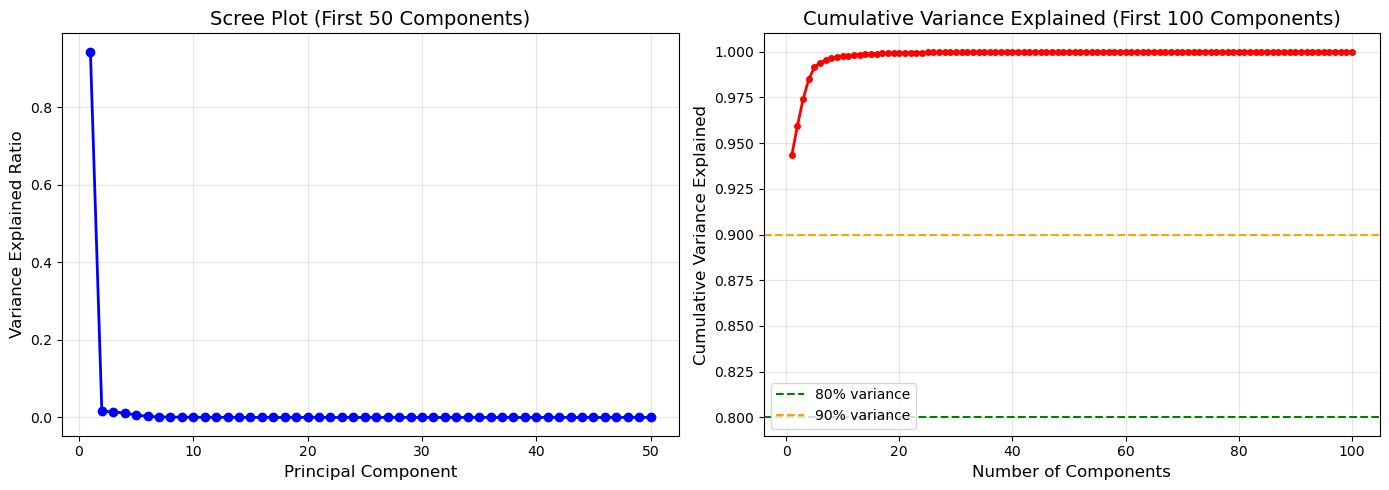

80% variance explained by 1 components
90% variance explained by 1 components


In [6]:
# Visualize explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.plot(range(1, min(51, len(pca.explained_variance_ratio_)+1)), 
         pca.explained_variance_ratio_[:50], 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Explained Ratio', fontsize=12)
ax1.set_title('Scree Plot (First 50 Components)', fontsize=14)
ax1.grid(True, alpha=0.3)

# Cumulative variance
ax2.plot(range(1, min(101, len(cumulative_variance)+1)), 
         cumulative_variance[:100], 'ro-', linewidth=2, markersize=4)
ax2.axhline(y=0.8, color='g', linestyle='--', label='80% variance')
ax2.axhline(y=0.9, color='orange', linestyle='--', label='90% variance')
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Variance Explained', fontsize=12)
ax2.set_title('Cumulative Variance Explained (First 100 Components)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"80% variance explained by {np.argmax(cumulative_variance >= 0.8) + 1} components")
print(f"90% variance explained by {np.argmax(cumulative_variance >= 0.9) + 1} components")


In [11]:
# Create PCA factor dataframe
# pca_components has shape (n_keywords, n_components) = (226, 121)
# Each row is a keyword, each column is a principal component score

pca_scores = pd.DataFrame(
    pca_components,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=trends_data.index  # Keywords as index
)

print(f"PCA scores matrix shape: {pca_scores.shape}")
print(f"Keywords: {pca_scores.shape[0]:,}")
print(f"Components: {pca_scores.shape[1]:,}")
print(f"\nFirst few keywords and their PC scores:")
print(pca_scores.iloc[:5, :5])

# Save PCA scores
pca_scores_path = DATA_DIR / 'pca_scores.csv'
pca_scores.to_csv(pca_scores_path)
print(f"\nPCA scores saved to: pca_scores.csv")

# Create a loadings matrix (which time periods contribute to each PC)
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose: (n_time_periods, n_components) = (121, 121)
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=trends_data.columns  # Time periods as index
)

loadings_path = DATA_DIR / 'pca_loadings.csv'
loadings.to_csv(loadings_path)
print(f"PCA loadings saved to: pca_loadings.csv")
print(f"Loadings shape: {loadings.shape}")

print(f"\nPC1 loadings (time periods with strongest loadings):")
print(f"Top 5 positive:")
print(loadings['PC1'].nlargest(5))
print(f"\nTop 5 negative:")
print(loadings['PC1'].nsmallest(5))


PCA scores matrix shape: (226, 121)
Keywords: 226
Components: 121

First few keywords and their PC scores:
                   PC1       PC2       PC3       PC4       PC5
keyword                                                       
5g           -2.115619 -0.111246  0.366204  0.248761  0.242254
advertising  -2.491879  0.184538 -0.145455 -0.295835  0.018225
aerospace    -3.287883  0.181321 -0.104402 -0.298367 -0.013857
airlines     23.803182 -4.179068 -1.809058 -0.653914 -2.957131
aluminum      0.144303 -0.302282  0.064843  0.055147  0.285855

PCA scores saved to: pca_scores.csv
PCA loadings saved to: pca_loadings.csv
Loadings shape: (121, 121)

PC1 loadings (time periods with strongest loadings):
Top 5 positive:
2022-01-01    0.093285
2020-02-01    0.093254
2023-02-01    0.093221
2022-08-01    0.093220
2024-02-01    0.093216
Name: PC1, dtype: float64

Top 5 negative:
2021-03-01    0.073814
2020-04-01    0.074916
2019-11-01    0.079142
2016-11-01    0.081773
2018-11-01    0.082086
Name:

In [ ]:
# Check which keywords are driving high variance
keyword_variances = trends_data.var(axis=1).sort_values(ascending=False)
print("Top 15 keywords by variance:")
print(keyword_variances.head(15))
print(f"\nBottom 10 keywords by variance:")
print(keyword_variances.tail(10))

# Normalize each keyword to unit variance (z-score normalization WITHIN keywords, not times)
trends_normalized = trends_data.copy()
for keyword in trends_normalized.index:
    trends_normalized.loc[keyword] = (trends_data.loc[keyword] - trends_data.loc[keyword].mean()) / trends_data.loc[keyword].std()

print(f"\nNormalized data (by keyword, not by time):")
print(trends_normalized.describe().T[['mean', 'std', 'min', 'max']].head(10))

# Run PCA on normalized data
pca_normalized = PCA()
pca_components_normalized = pca_normalized.fit_transform(trends_normalized.values)
cumulative_variance_normalized = np.cumsum(pca_normalized.explained_variance_ratio_)

print(f"\n\nPCA on KEYWORD-NORMALIZED data:")
print(f"Variance explained by first 15 components:")
for i in range(min(15, len(pca_normalized.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_normalized.explained_variance_ratio_[i]:.4f} ({cumulative_variance_normalized[i]:.4f} cumulative)")

print(f"\nVariance explained summary (NORMALIZED):")
print(f"  First 1 PC: {cumulative_variance_normalized[0]:.4f} ({cumulative_variance_normalized[0]*100:.2f}%)")
print(f"  First 3 PCs: {cumulative_variance_normalized[2]:.4f} ({cumulative_variance_normalized[2]*100:.2f}%)")
print(f"  First 10 PCs: {cumulative_variance_normalized[9]:.4f} ({cumulative_variance_normalized[9]*100:.2f}%)")
